In [1]:
import functools
import warnings

import botocore
import boto3
from cliffs_delta import cliffs_delta
from iterpop import iterpop as ip
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import pandas as pd
from pandas.util import hash_pandas_object
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

from dishpylib.pyhelpers import fit_control_t_distns

warnings.filterwarnings("ignore")


In [2]:
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervm7g52i
interpreter: 3.10.12 (main, Jul 15 2026, 23:40:17) [GCC 11.4.0]
notebook name: 2025-11-26-replaysmutagenized50
notebook path: /home/runner/work/oee4/oee4/binder/2025-11-26-replaysmutagenized50.ipynb
revision: bdac574
timestamp: 2026-09-22T01:26:43Z00:00

IPython==7.16.1
packaging==26.2


In [4]:
teeplot_subdir = "2025-11-26-replaysmutagenized50"


In [5]:
@functools.lru_cache
def get_control_t_distns( bucket, endeavor, stint ):

    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    control_competitions, = bucket_handle.objects.filter(
        Prefix=f'endeavor={endeavor}/control-competitions/stage=2+what=collated/stint={stint}/',
    )

    control_df = pd.read_csv(
        f's3://{bucket}/{control_competitions.key}',
    )

    return fit_control_t_distns(control_df[
        control_df["Root ID"] == 1
    ].copy())


In [6]:
def preprocess_competition_fitnesses(competitions_df, control_fits_df):
    # preprocess data
    @functools.lru_cache
    def h0_fit(series):
        return ip.popsingleton(
            control_fits_df[control_fits_df["Series"] == series].to_dict(
                orient="records",
            )
        )

    competitions_df["p"] = competitions_df.apply(
        lambda row: scipy_stats.t.cdf(
            row["Fitness Differential"],
            h0_fit(row["genome series"])["Fit Degrees of Freedom"],
            loc=h0_fit(row["genome series"])["Fit Loc"],
            scale=h0_fit(row["genome series"])["Fit Scale"],
        ),
        axis=1,
    )
    competitions_df["Is Less Fit"] = competitions_df["p"] < 1.0 / 40
    competitions_df["Is More Fit"] = competitions_df["p"] > (1.0 -  1.0 / 40)
    competitions_df["Is Neutral"] = ~(
        competitions_df["Is Less Fit"] | competitions_df["Is More Fit"]
    )
    competitions_df["Relative Fitness"] = competitions_df.apply(
        lambda row: (
            "Significantly Advantageous"
            if row["Is More Fit"]
            else (
                "Significantly Deleterious" if row["Is Less Fit"] else "Neutral"
            )
        ),
        axis=1,
    )

    return competitions_df


# get data


In [7]:
dfs = []
for bucket in [
    "prq49-restint-mut50-selfmut00bb-rep01-step00",
    "prq49-restint-mut50-truemut00bb-rep01-step00",
]:
    if "step" in bucket:
        step = int(bucket.split("-step")[-1]) + 1
    else:
        step = 0
    if "restint" in bucket:
        kind = bucket.split("-")[3]
    else:
        kind = None
    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    for stint in tqdm(range(32, 101)):
        try:
            series_profiles, = bucket_handle.objects.filter(
                Prefix=f'endeavor=16/variant-competitions/stage=3+what=collated/stint={stint}/',
            )
            import warnings
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
            control_fits_df = get_control_t_distns(bucket, 16, stint)
            df = pd.read_csv(
                f's3://{bucket}/{series_profiles.key}',
                compression='xz',
            )
            df = df[df["Competition Series"] == 16005]
            df = df[df["genome variation"] != "master"].copy()
            df = df.groupby("genome variation").mean(numeric_only=True).reset_index()
            # print(f"{bucket=}, {stint=}, {len(df)=}, {kind=}, {step=}")
            df["Stint"] = stint
            dfdigest = '{:x}'.format( hash_pandas_object( df ).sum() )
            df = preprocess_competition_fitnesses(df, control_fits_df)

            df = df.copy()
            df["bucket"] = bucket
            df["Source Stint"] = stint - step
            df["kind"] = kind
            dfs.append(df)
        except:
            print(f"Skipping {bucket=}, {stint=}")


 54%|█████▎    | 37/69 [00:14<00:12,  2.46it/s]

Skipping bucket='prq49-restint-mut50-selfmut00bb-rep01-step00', stint=69


 78%|███████▊  | 54/69 [00:20<00:05,  2.57it/s]

Skipping bucket='prq49-restint-mut50-selfmut00bb-rep01-step00', stint=86


100%|██████████| 69/69 [00:32<00:00,  2.13it/s]


In [8]:
df = pd.concat(dfs)


In [9]:
df.to_csv("replays-mutagenized.csv")


In [10]:
pd.options.display.max_columns = None
df["target idx"] = df["genome variation"].str.replace("%Nop-0", "").str.replace("i", "").astype(int)


In [11]:
dfx = df[
    df["Root ID"] == 1
].groupby(["Stint", "bucket", "Source Stint", "kind"]).agg(
    {
        "Is More Fit": "sum",
        "Is Less Fit": "sum",
        "Is Neutral": "sum",
        "target idx": "max",
        "genome variation": "count",
    },
)
dfx


Is More Fit  \
Stint bucket                                       Source Stint kind                       
32    prq49-restint-mut50-selfmut00bb-rep01-step00 31           selfmut00bb            1   
      prq49-restint-mut50-truemut00bb-rep01-step00 31           truemut00bb           11   
33    prq49-restint-mut50-selfmut00bb-rep01-step00 32           selfmut00bb            5   
      prq49-restint-mut50-truemut00bb-rep01-step00 32           truemut00bb            5   
34    prq49-restint-mut50-selfmut00bb-rep01-step00 33           selfmut00bb            1   
...                                                                                  ...   
98    prq49-restint-mut50-truemut00bb-rep01-step00 97           truemut00bb            7   
99    prq49-restint-mut50-selfmut00bb-rep01-step00 98           selfmut00bb            0   
      prq49-restint-mut50-truemut00bb-rep01-step00 98           truemut00bb            3   
100   prq49-restint-mut50-selfmut00bb-rep01-step00 99           selfmut00bb            4   
      prq49-restint-mut50-truemut00bb-rep01-step00 99           truemut00bb            4   

                                                                             Is Less Fit  \
Stint bucket                                       Source Stint kind                       
32    prq49-restint-mut50-selfmut00bb-rep01-step00 31           selfmut00bb           12   
      prq49-restint-mut50-truemut00bb-rep01-step00 31           truemut00bb           17   
33    prq49-restint-mut50-selfmut00bb-rep01-step00 32           selfmut00bb           13   
      prq49-restint-mut50-truemut00bb-rep01-step00 32           truemut00bb           21   
34    prq49-restint-mut50-selfmut00bb-rep01-step00 33           selfmut00bb           31   
...                                                                                  ...   
98    prq49-restint-mut50-truemut00bb-rep01-step00 97           truemut00bb           16   
99    prq49-restint-mut50-selfmut00bb-rep01-step00 98           selfmut00bb           30   
      prq49-restint-mut50-truemut00bb-rep01-step00 98           truemut00bb           16   
100   prq49-restint-mut50-selfmut00bb-rep01-step00 99           selfmut00bb            7   
      prq49-restint-mut50-truemut00bb-rep01-step00 99           truemut00bb           14   

                                                                             Is Neutral  \
Stint bucket                                       Source Stint kind                      
32    prq49-restint-mut50-selfmut00bb-rep01-step00 31           selfmut00bb          26   
      prq49-restint-mut50-truemut00bb-rep01-step00 31           truemut00bb         754   
33    prq49-restint-mut50-selfmut00bb-rep01-step00 32           selfmut00bb         572   
      prq49-restint-mut50-truemut00bb-rep01-step00 32           truemut00bb          92   
34    prq49-restint-mut50-selfmut00bb-rep01-step00 33           selfmut00bb          81   
...                                                                                 ...   
98    prq49-restint-mut50-truemut00bb-rep01-step00 97           truemut00bb         725   
99    prq49-restint-mut50-selfmut00bb-rep01-step00 98           selfmut00bb          77   
      prq49-restint-mut50-truemut00bb-rep01-step00 98           truemut00bb          67   
100   prq49-restint-mut50-selfmut00bb-rep01-step00 99           selfmut00bb          50   
      prq49-restint-mut50-truemut00bb-rep01-step00 99           truemut00bb          68   

                                                                             target idx  \
Stint bucket                                       Source Stint kind                      
32    prq49-restint-mut50-selfmut00bb-rep01-step00 31           selfmut00bb         716   
      prq49-restint-mut50-truemut00bb-rep01-step00 31           truemut00bb         831   
33    prq49-restint-mut50-selfmut00bb-rep01-step00 32           selfmut00bb         996   
      prq49-restint-mut50-truemut00bb-rep01-

In [12]:
dfx = dfx.reset_index(drop=False)
dfx["Step"] = dfx["Stint"] - dfx["Source Stint"]


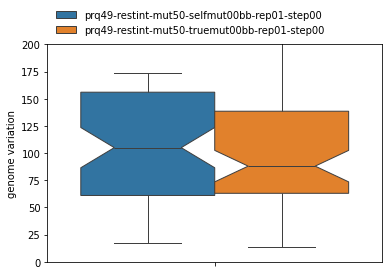

In [13]:
ax = sns.boxplot(
    data=dfx[
        (dfx["Step"] > 0)
        & (dfx["Stint"] > 33)
    ],
    # x="Stint",
    y="genome variation",
    hue="bucket",
    notch=True,
    # legend=False,
)
ax.set_ylim(0, 200)
sns.move_legend(
    ax,
    "lower left",
    bbox_to_anchor=(0, 1),
    title="",
    frameon=False,
)


In [14]:
dfx["epoch"] = dfx["Stint"] // 10


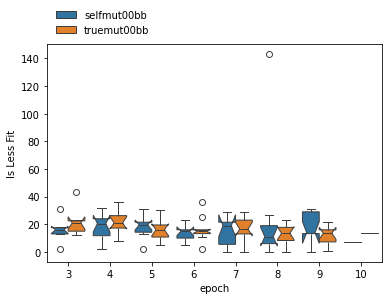

In [15]:
ax = sns.boxplot(
    data=dfx[
        (dfx["Step"] > 0)
        & (dfx["Stint"] > 32)
    ],
    x="epoch",
    y="Is Less Fit",
    hue="kind",
    notch=True,
)
sns.move_legend(
    ax,
    "lower left",
    bbox_to_anchor=(0, 1),
    title="",
    frameon=False,
)


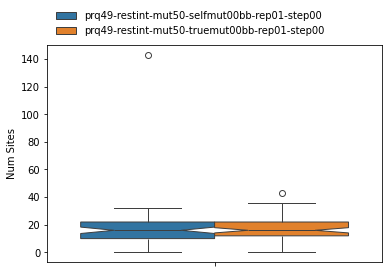

In [16]:
ax = sns.boxplot(
    data=dfx[(dfx["Stint"] > 32)],
    y="Is Less Fit",
    hue="bucket",
    notch=True,
    legend=True,
)
ax.set_ylabel("Num Sites")
sns.move_legend(
    ax,
    "lower left",
    bbox_to_anchor=(0, 1),
    title="",
    frameon=False,
)


In [17]:
scipy_stats.mannwhitneyu(
    dfx[
        (dfx["bucket"] == "prq49-restint-mut50-selfmut00bb-rep01-step00")
        & (dfx["Stint"] > 32)
    ]["Is Less Fit"],
    dfx[
        (dfx["bucket"] == "prq49-restint-mut50-truemut00bb-rep01-step00")
        & (dfx["Stint"] > 32)
    ]["Is Less Fit"],
    alternative='greater',
)


MannwhitneyuResult(statistic=2204.5, pvalue=0.5707211670882336)

In [18]:
cliffs_delta(
    dfx[
        (dfx["bucket"] == "prq49-restint-mut50-selfmut00bb-rep01-step00")
        & (dfx["Stint"] > 32)
    ]["Is Less Fit"],
    dfx[
        (dfx["bucket"] == "prq49-restint-mut50-truemut00bb-rep01-step00")
        & (dfx["Stint"] > 32)
    ]["Is Less Fit"],
)


(-0.017602495543672013, 'negligible')

In [19]:
dark_palette = [sns.color_palette("Dark2")[0], sns.color_palette("Dark2")[4]]
light_palette = ["#a3cf73", "#6dceb1"]


teeplots/2025-11-26-replaysmutagenized50/hue=bucket+inner=quart+viz=violinplot+x=bucket+y=is-less-fit+ext=.pdf
teeplots/2025-11-26-replaysmutagenized50/hue=bucket+inner=quart+viz=violinplot+x=bucket+y=is-less-fit+ext=.png


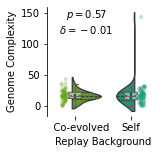

In [20]:
with tp.teed(
    sns.violinplot,
    data=dfx[(dfx["Stint"] > 32)],
    y="Is Less Fit",
    x="bucket",
    hue="bucket",
    order=[
        "prq49-restint-mut50-truemut00bb-rep01-step00",
        "prq49-restint-mut50-selfmut00bb-rep01-step00",
    ],
    hue_order=[
        "prq49-restint-mut50-selfmut00bb-rep01-step00",
        "prq49-restint-mut50-truemut00bb-rep01-step00",
    ],
    common_norm=True,
    cut=True,
    dodge=True,
    gap=-0.3,
    inner="quart",
    legend=False,
    palette=dark_palette,
    split=True,
    teeplot_subdir=teeplot_subdir,
) as ax:
    sns.boxplot(
        data=dfx[(dfx["Stint"] > 32)],
        x="bucket",
        y="Is Less Fit",
        hue="bucket",
        notch=True,
        legend=False,
        gap=0.7,
        showfliers=False,
        palette=light_palette,
        order=[
            "prq49-restint-mut50-truemut00bb-rep01-step00",
            "prq49-restint-mut50-selfmut00bb-rep01-step00",
        ],
        hue_order=[
            "prq49-restint-mut50-truemut00bb-rep01-step00",
            "prq49-restint-mut50-selfmut00bb-rep01-step00",
        ],
    )
    sns.stripplot(
        data=dfx[(dfx["Stint"] > 32)],
        x="bucket",
        y="Is Less Fit",
        hue="bucket",
        dodge=True,
        palette=dark_palette[::-1],
        order=[
            "prq49-restint-mut50-truemut00bb-rep01-step00",
            "prq49-restint-mut50-selfmut00bb-rep01-step00",
        ],
        hue_order=[
            "prq49-restint-mut50-truemut00bb-rep01-step00",
            "prq49-restint-mut50-selfmut00bb-rep01-step00",
        ],
        alpha=0.3,
        legend=False,
        size=4,
    )
    sns.barplot(
        data=dfx[(dfx["Stint"] > 32)],
        x="bucket",
        y="Is Less Fit",
        order=[
            "prq49-restint-mut50-truemut00bb-rep01-step00",
            "prq49-restint-mut50-selfmut00bb-rep01-step00",
        ],
        hue_order=[
            "prq49-restint-mut50-truemut00bb-rep01-step00",
            "prq49-restint-mut50-selfmut00bb-rep01-step00",
        ],
        alpha=0.0,
        ax=ax,
        estimator=np.median,
        gap=0.2,
        legend=False,
    )

    # handles, __ = plt.gca().get_legend_handles_labels()
    # ghost_patch = mpatches.Patch(color='none', label='Replay')

    # ax.legend(
    #     columnspacing=0.8,
    #     handles=[ghost_patch, handles[1], handles[0]],
    #     labels=["Background ", "Self", "Eco"],
    #     loc="lower center",
    #     bbox_to_anchor=(.43, 1),
    #     frameon=False,
    #     ncol=3,
    #     title=None,
    # )

    ax.set_ylabel("Num Sites")
    # ax.get_xaxis().set_visible(False)
    ax.set_xlabel("Replay Background")
    ax.set_ylabel("Genome Complexity")
    ax.figure.set_size_inches(2, 2)
    ax.annotate(
        "$p = 0.57$\n$\delta=-0.01$",
        xy=(0.35, 0.75),
        xycoords='axes fraction',
        ha='center',
        fontsize=10,
    )
    sns.despine(ax=ax, bottom=True)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["    Co-evolved", "Self"])


teeplots/2025-11-26-replaysmutagenized50/clip=100+hue=bucket+inner=quart+viz=violinplot+x=bucket+y=is-less-fit+ext=.pdf
teeplots/2025-11-26-replaysmutagenized50/clip=100+hue=bucket+inner=quart+viz=violinplot+x=bucket+y=is-less-fit+ext=.png


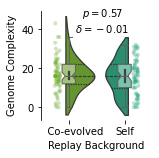

In [21]:
fil = (
    (dfx["Stint"] > 32)
    & (dfx["Is Less Fit"] < 100)
)
with tp.teed(
    sns.violinplot,
    data=dfx[fil],
    y="Is Less Fit",
    x="bucket",
    hue="bucket",
    order=[
        "prq49-restint-mut50-truemut00bb-rep01-step00",
        "prq49-restint-mut50-selfmut00bb-rep01-step00",
    ],
    hue_order=[
        "prq49-restint-mut50-selfmut00bb-rep01-step00",
        "prq49-restint-mut50-truemut00bb-rep01-step00",
    ],
    common_norm=True,
    cut=True,
    dodge=True,
    inner="quart",
    legend=False,
    palette=dark_palette,
    split=True,
    gap=-0.3,
    teeplot_subdir=teeplot_subdir,
    teeplot_outattrs={"clip": 100},
) as ax:
    sns.boxplot(
        data=dfx[fil],
        x="bucket",
        y="Is Less Fit",
        hue="bucket",
        notch=True,
        legend=False,
        gap=0.7,
        showfliers=False,
        palette=light_palette,
        order=[
            "prq49-restint-mut50-truemut00bb-rep01-step00",
            "prq49-restint-mut50-selfmut00bb-rep01-step00",
        ],
        hue_order=[
            "prq49-restint-mut50-truemut00bb-rep01-step00",
            "prq49-restint-mut50-selfmut00bb-rep01-step00",
        ],
    )
    sns.stripplot(
        data=dfx[fil],
        x="bucket",
        y="Is Less Fit",
        hue="bucket",
        dodge=True,
        palette=dark_palette[::-1],
        order=[
            "prq49-restint-mut50-truemut00bb-rep01-step00",
            "prq49-restint-mut50-selfmut00bb-rep01-step00",
        ],
        hue_order=[
            "prq49-restint-mut50-truemut00bb-rep01-step00",
            "prq49-restint-mut50-selfmut00bb-rep01-step00",
        ],
        alpha=0.3,
        legend=False,
        size=4,
    )
    sns.barplot(
        data=dfx[fil],
        x="bucket",
        y="Is Less Fit",
        alpha=0.0,
        ax=ax,
        estimator=np.median,
        gap=0.2,
        order=[
            "prq49-restint-mut50-truemut00bb-rep01-step00",
            "prq49-restint-mut50-selfmut00bb-rep01-step00",
        ],
        hue_order=[
            "prq49-restint-mut50-truemut00bb-rep01-step00",
            "prq49-restint-mut50-selfmut00bb-rep01-step00",
        ],
        legend=False,
    )

    # handles, __ = plt.gca().get_legend_handles_labels()
    # ghost_patch = mpatches.Patch(color='none', label='Replay')

    # ax.legend(
    #     columnspacing=0.8,
    #     handles=[ghost_patch, handles[1], handles[0]],
    #     labels=["Replay ", "self bg", "true bg"],
    #     loc="lower center",
    #     bbox_to_anchor=(.43, 1),
    #     frameon=False,
    #     ncol=3,
    #     title=None,
    # )

    ax.set_ylabel("Num Sites")
    # ax.get_xaxis().set_visible(False)
    ax.set_xlabel("Replay Background")
    ax.set_ylabel("Genome Complexity")
    ax.figure.set_size_inches(2, 2)
    ax.annotate(
        "$p = 0.57$\n$\delta=-0.01$",
        xy=(0.55, 0.8),
        xycoords="axes fraction",
        ha="center",
        fontsize=10,
    )
    sns.despine(ax=ax, bottom=True)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["    Co-evolved", "Self"])


teeplots/2025-11-26-replaysmutagenized50/clip=62+hue=bucket+inner=quart+viz=violinplot+x=bucket+y=is-less-fit+ext=.pdf
teeplots/2025-11-26-replaysmutagenized50/clip=62+hue=bucket+inner=quart+viz=violinplot+x=bucket+y=is-less-fit+ext=.png


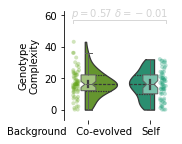

In [22]:
fil = (
    (dfx["Stint"] > 32)
    & (dfx["Is Less Fit"] < 100)
)
with tp.teed(
    sns.violinplot,
    data=dfx[fil],
    y="Is Less Fit",
    x="bucket",
    hue="bucket",
    order=[
        "prq49-restint-mut50-truemut00bb-rep01-step00",
        "prq49-restint-mut50-selfmut00bb-rep01-step00",
    ],
    hue_order=[
        "prq49-restint-mut50-selfmut00bb-rep01-step00",
        "prq49-restint-mut50-truemut00bb-rep01-step00",
    ],
    common_norm=True,
    cut=0.0,
    dodge=True,
    inner="quart",
    legend=False,
    palette=dark_palette,
    split=True,
    gap=-0.3,
    teeplot_subdir=teeplot_subdir,
    teeplot_outattrs={"clip": 62},
) as ax:
    sns.boxplot(
        data=dfx[fil],
        x="bucket",
        y="Is Less Fit",
        hue="bucket",
        notch=True,
        legend=False,
        gap=0.7,
        showfliers=False,
        palette=light_palette,
        order=[
            "prq49-restint-mut50-truemut00bb-rep01-step00",
            "prq49-restint-mut50-selfmut00bb-rep01-step00",
        ],
        hue_order=[
            "prq49-restint-mut50-truemut00bb-rep01-step00",
            "prq49-restint-mut50-selfmut00bb-rep01-step00",
        ],
    )
    sns.stripplot(
        data=dfx[fil],
        x="bucket",
        y="Is Less Fit",
        hue="bucket",
        dodge=True,
        palette=dark_palette[::-1],
        order=[
            "prq49-restint-mut50-truemut00bb-rep01-step00",
            "prq49-restint-mut50-selfmut00bb-rep01-step00",
        ],
        hue_order=[
            "prq49-restint-mut50-truemut00bb-rep01-step00",
            "prq49-restint-mut50-selfmut00bb-rep01-step00",
        ],
        alpha=0.3,
        legend=False,
        size=4,
    )
    sns.barplot(
        data=dfx[fil],
        x="bucket",
        y="Is Less Fit",
        alpha=0.0,
        ax=ax,
        estimator=np.median,
        gap=0.2,
        order=[
            "prq49-restint-mut50-truemut00bb-rep01-step00",
            "prq49-restint-mut50-selfmut00bb-rep01-step00",
        ],
        hue_order=[
            "prq49-restint-mut50-truemut00bb-rep01-step00",
            "prq49-restint-mut50-selfmut00bb-rep01-step00",
        ],
        legend=False,
    )

    # handles, __ = plt.gca().get_legend_handles_labels()
    # ghost_patch = mpatches.Patch(color='none', label='Replay')

    # ax.legend(
    #     columnspacing=0.8,
    #     handles=[ghost_patch, handles[1], handles[0]],
    #     labels=["Replay ", "self bg", "true bg"],
    #     loc="lower center",
    #     bbox_to_anchor=(.43, 1),
    #     frameon=False,
    #     ncol=3,
    #     title=None,
    # )

    ax.set_ylabel("Num Sites")
    # ax.get_xaxis().set_visible(False)
    ax.figure.set_size_inches(2, 2)
    ax.set_ylabel("Genotype\nComplexity")
    ax.annotate(
        "$p = 0.57$ $\delta=-0.01$",
        color="lightgray",
        xy=(0.5, 0.95),
        xycoords="axes fraction",
        ha="center",
        fontsize=10,
    )
    sns.despine(ax=ax, bottom=True)
    ax.set_ylim((-6.497935262506936, 62.497935262506935))
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["          Co-evolved", "Self"])

    x1, x2 = -0.25, 1.25
    y_max = 54
    y_h = 2
    y_pos = y_max + 1

    ax.plot(
        [x1, x1, x2, x2],
        [y_pos, y_pos+y_h, y_pos+y_h, y_pos],
        color="lightgray",
        lw=0.9,
    )

    ax.set_xlabel("")
    ax.text(
        -0.35,
        -10.5,
        "Background",
        ha="right",
        va="top",
    )
